In [16]:
import torch
import lerobot
import numpy as np


from PIL import Image
from sympy.abc import a
from IPython.display import display
from torchvision.transforms.functional import to_pil_image

# lerobot-train \
#   --dataset.repo_id="rafafelixphd/dataset-trial-1" \
#   --output_dir=outputs/train/act_so101_test \
#   --job_name=act_so101_test \
#   --policy.type=act \
#   --policy.device=cuda \
#   --policy.repo_id="rafafelixphd/my_policy" \
#   --wandb.enable=true \
#   --batch_size=1

In [5]:
from lerobot.datasets.factory import make_dataset
from lerobot.configs.train import TrainPipelineConfig
from lerobot.configs.default import DatasetConfig
from lerobot.policies import ACTConfig

cfg = TrainPipelineConfig(
        dataset=DatasetConfig(repo_id="rafafelixphd/dataset-trial-1"),
        output_dir="outputs/train/act_so101_test",
        job_name="act_so101_test",  
        policy=ACTConfig(repo_id='local/my_policy', device='mps')
    )
cfg.validate()

dataset = make_dataset(cfg)

In [27]:
sample = dataset[0]
print(list(sample.keys()))

['observation.images.front', 'action', 'observation.state', 'timestamp', 'frame_index', 'episode_index', 'index', 'task_index', 'action_is_pad', 'task']


In [55]:
# imarray = sample['observation.images.front'].squeeze().permute(1, 2, 0).numpy().astype(np.uint8)
image = to_pil_image(sample['observation.images.front'])


(798, 1275, 3)
(798, 1275, 3)


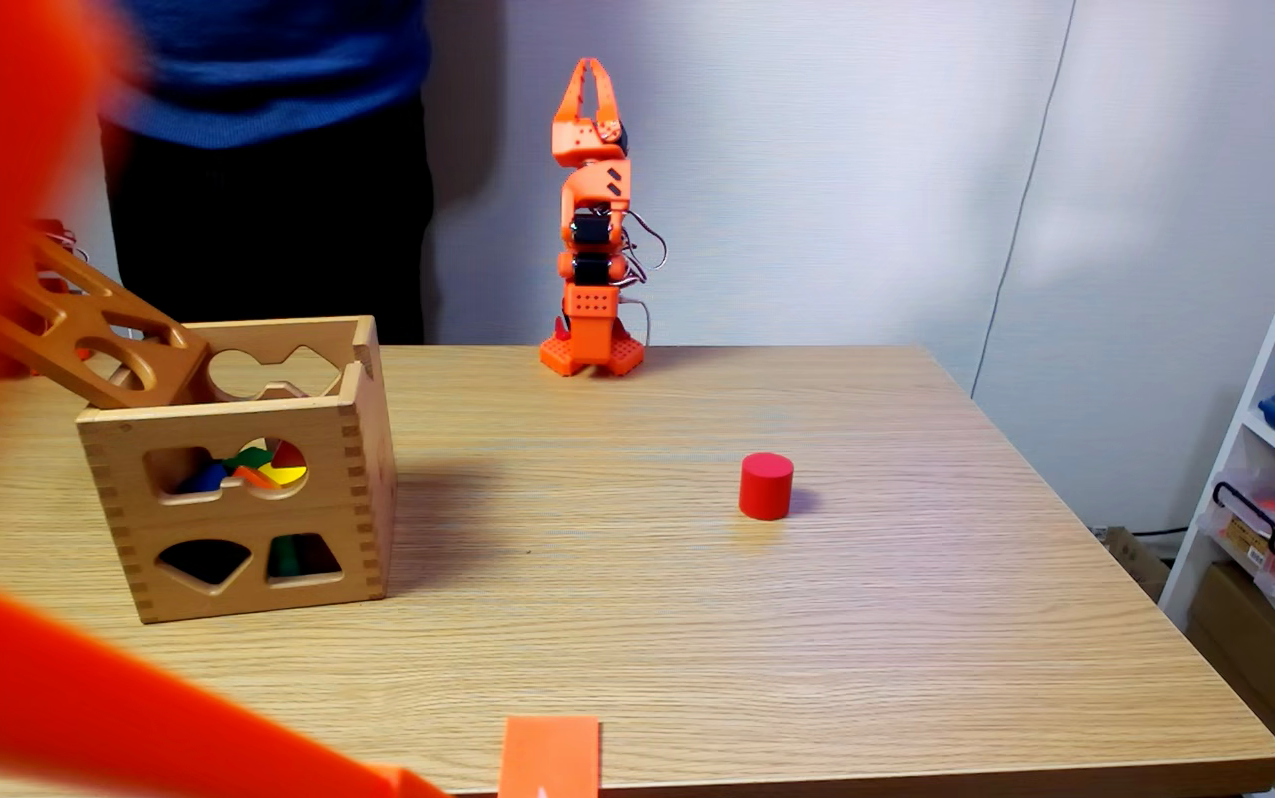

In [102]:
# Image.fromarray(np.array(image)[:,50:1325])
left_side = np.array(image)[:-10,50:1325]
print(f"{left_side.shape}")
right_side = np.array(image)[:-10,1330:2605]
print(f"{right_side.shape}")
Image.fromarray(left_side)
# Image.fromarray(right_side)

In [ ]:
import torch
from lerobot.datasets.utils import cycle

dataloader = torch.utils.data.DataLoader(
    dataset,
    num_workers=4,
    batch_size=2,
    shuffle=True,
    sampler=None,
    pin_memory=False,
    drop_last=False,
    prefetch_factor=2)

dl_iter = cycle(dataloader)

In [ ]:
batch = next(dl_iter)

In [ ]:
batch.keys()

In [ ]:
batch['observation.images.front'].shape

# Reading Parquet

In [ ]:
# /Users/rafaelfelix/.cache/huggingface/lerobot//rafafelixphd/dataset-trial-1/data/chunk-000/file-001.parquet

import pandas as pd

parquet_path = "/Users/rafaelfelix/.cache/huggingface/lerobot//rafafelixphd/dataset-trial-1/data/chunk-000/file-001.parquet"
df = pd.read_parquet(parquet_path)
sample = df.iloc[0]

In [26]:
dataset.meta.video_keys

['observation.images.front']

In [17]:
absolute_to_relative_idx = {
            abs_idx.item() if isinstance(abs_idx, torch.Tensor) else abs_idx: rel_idx
            for rel_idx, abs_idx in enumerate(dataset.hf_dataset["index"])
        }

def get_query_timestamps(
    datum,
    current_ts: float,
    query_indices: dict[str, list[int]] | None = None,
) -> dict[str, list[float]]:
    query_timestamps = {}

    for key in datum.meta.video_keys:
        if query_indices is not None and key in query_indices:
            if absolute_to_relative_idx is not None:
                relative_indices = [absolute_to_relative_idx[idx] for idx in query_indices[key]]
                timestamps = datum.hf_dataset[relative_indices]["timestamp"]
            else:
                timestamps = datum.hf_dataset[query_indices[key]]["timestamp"]
            query_timestamps[key] = torch.stack(timestamps).tolist()
        else:
            query_timestamps[key] = [current_ts]

    return query_timestamps

def get_query_indices(datum, idx: int, ep_idx: int) -> tuple[dict[str, list[int | bool]]]:
    ep = datum.meta.episodes[ep_idx]
    ep_start = ep["dataset_from_index"]
    ep_end = ep["dataset_to_index"]
    query_indices = {
        key: [max(ep_start, min(ep_end - 1, idx + delta)) for delta in delta_idx]
        for key, delta_idx in datum.delta_indices.items()
    }
    padding = {  # Pad values outside of current episode range
        f"{key}_is_pad": torch.BoolTensor(
            [(idx + delta < ep_start) | (idx + delta >= ep_end) for delta in delta_idx]
        )
        for key, delta_idx in datum.delta_indices.items()
    }
    return query_indices, padding

In [18]:
def query_videos(datum, query_timestamps: dict[str, list[float]], ep_idx: int) -> dict[str, torch.Tensor]:
    """Note: When using data workers (e.g. DataLoader with num_workers>0), do not call this function
    in the main process (e.g. by using a second Dataloader with num_workers=0). It will result in a
    Segmentation Fault. This probably happens because a memory reference to the video loader is created in
    the main process and a subprocess fails to access it.
    """
    ep = datum.meta.episodes[ep_idx]
    item = {}
    for vid_key, query_ts in query_timestamps.items():
        # Episodes are stored sequentially on a single mp4 to reduce the number of files.
        # Thus we load the start timestamp of the episode on this mp4 and,
        # shift the query timestamp accordingly.
        from_timestamp = ep[f"videos/{vid_key}/from_timestamp"]
        shifted_query_ts = [from_timestamp + ts for ts in query_ts]

        video_path = datum.root / datum.meta.get_video_file_path(ep_idx, vid_key)
        frames = lerobot.datasets.video_utils.decode_video_frames(video_path, shifted_query_ts, datum.tolerance_s, datum.video_backend)
        item[vid_key] = frames.squeeze(0)

    return item

In [25]:
query_timestamps

{'observation.images.front': [0.0]}

In [20]:
idx = 0
item = dataset.hf_dataset[idx]
ep_idx = item["episode_index"].item()
current_ts = item["timestamp"].item()
query_indices, padding = get_query_indices(datum=dataset,idx=idx, ep_idx=ep_idx)
query_timestamps = get_query_timestamps(datum=dataset, current_ts=current_ts, query_indices=query_indices)
video_frames = query_videos(datum=dataset, query_timestamps=query_timestamps, ep_idx=ep_idx)

# dataset.meta.get_video_file_path(ep_idx, vid_key)

objc[80351]: Class AVFFrameReceiver is implemented in both /Users/rafaelfelix/.pyenv/versions/3.10.16/envs/r2b-3.10/lib/python3.10/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x10c6ec3a8) and /opt/homebrew/Cellar/ffmpeg@7/7.1.3_1/lib/libavdevice.61.3.100.dylib (0x163560328). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
objc[80351]: Class AVFAudioReceiver is implemented in both /Users/rafaelfelix/.pyenv/versions/3.10.16/envs/r2b-3.10/lib/python3.10/site-packages/av/.dylibs/libavdevice.61.3.100.dylib (0x10c6ec3f8) and /opt/homebrew/Cellar/ffmpeg@7/7.1.3_1/lib/libavdevice.61.3.100.dylib (0x163560378). This may cause spurious casting failures and mysterious crashes. One of the duplicates must be removed or renamed.
